
### Task 1: One-Sample t-Test

**Scenario:** A coffee-shop chain claims that the average wait time at their stores is 4.0 minutes. You have collected wait times (in minutes) from a random sample of 35 visits.

1. Generate (or load) the sample data. If generating, use something like:

```python
wait_times = np.random.normal(loc=4.3, scale=1.2, size=35)
```

2. State the null and alternative hypotheses in a Markdown cell.
3. Run `st.ttest_1samp(wait_times, popmean=4.0)`.
4. Report the t-statistic and p-value.
5. At α = 0.05, state whether you reject or fail to reject H₀.
6. Write a one-sentence plain-language interpretation (e.g. "There is / is not sufficient evidence that the average wait time differs from 4 minutes.").

In [48]:

import numpy as np
import pandas as pd
import scipy.stats as st
import matplotlib.pyplot as plt
import seaborn as sns

np.random.seed(42)

In [49]:
import numpy as np
import scipy.stats as st

np.random.seed(42)

wait_times = np.random.normal(loc=4.3, scale=1.2, size=35)

### Hypotheses

- H₀ (Null hypothesis): The average wait time is 4.0 minutes (μ = 4.0)
- H₁ (Alternative hypothesis): The average wait time is different from 4.0 minutes (μ ≠ 4.0)

In [50]:
t_stat, p_value = st.ttest_1samp(wait_times, popmean=4.0)

print("t-statistic:", t_stat)
print("p-value:", p_value)

t-statistic: 0.7450545455494864
p-value: 0.4613582663773366


In [51]:
alpha = 0.05

if p_value < alpha:
    print("Reject H₀")
else:
    print("Fail to reject H₀")

Fail to reject H₀


There is not sufficient evidence that the average wait time differs from 4 minutes.

### Task 2: Independent Two-Sample t-Test

**Scenario:** An e-commerce company ran an A/B test on its checkout page. Group A (control, n = 50) saw the old design; Group B (treatment, n = 50) saw a streamlined design. The metric is order value in euros.

1. Generate (or load) data for both groups. Example:

```python
group_a = np.random.normal(loc=52, scale=12, size=50)
group_b = np.random.normal(loc=57, scale=14, size=50)
```

2. State hypotheses (two-tailed: means are equal vs. not equal).
3. Before running the test, check the **equal-variance assumption**:
   - Compute the variance of each group.
   - Run Levene's test (`st.levene`). Report the result.
4. Based on the Levene result, choose the appropriate test:
   - Equal variances → `st.ttest_ind(a, b, equal_var=True)`
   - Unequal variances → `st.ttest_ind(a, b, equal_var=False)` (Welch's t-test)
5. Report the t-statistic and p-value.
6. State your decision and a plain-language interpretation.


In [52]:
np.random.seed(42)

group_a = np.random.normal(loc=52, scale=12, size=50)
group_b = np.random.normal(loc=57, scale=14, size=50)

### Hypotheses

- H₀ (Null hypothesis): The mean order values are equal (μ₁ = μ₂)
- H₁ (Alternative hypothesis): The mean order values are different (μ₁ ≠ μ₂)

In [53]:
var_a = np.var(group_a, ddof=1)
var_b = np.var(group_b, ddof=1)

print("Variance A:", var_a)
print("Variance B:", var_b)

Variance A: 125.53018477388542
Variance B: 149.83106001071917


In [54]:
levene_stat, levene_p = st.levene(group_a, group_b)

print("Levene test statistic:", levene_stat)
print("Levene p-value:", levene_p)

Levene test statistic: 0.20905767482138826
Levene p-value: 0.6485189712161833


In [55]:
if levene_p < 0.05:
    print("Variances are NOT equal → use Welch's t-test")
    t_stat, p_value = st.ttest_ind(group_a, group_b, equal_var=False)
else:
    print("Variances are equal → use standard t-test")
    t_stat, p_value = st.ttest_ind(group_a, group_b, equal_var=True)

print("t-statistic:", t_stat)
print("p-value:", p_value)

Variances are equal → use standard t-test
t-statistic: -3.3896353481086083
p-value: 0.0010096788856040154


In [56]:
alpha = 0.05

if p_value < alpha:
    print("Reject H₀")
else:
    print("Fail to reject H₀")

Reject H₀


There is sufficient evidence that the average order value differs between the two groups.

### Task 3: Paired t-Test

**Scenario:** A company measures employee productivity scores before and after a new workflow tool is introduced. The same 30 employees are measured at both time points.

1. Generate (or load) paired data:

```python
before = np.random.normal(loc=70, scale=8, size=30)
after = before + np.random.normal(loc=3, scale=5, size=30)
```

2. State hypotheses (one-tailed or two-tailed — justify your choice in a Markdown cell).
3. Compute the differences (`after - before`) and briefly inspect them (histogram or box plot).
4. Run `st.ttest_rel(after, before)`.
5. Report the t-statistic and p-value.
6. State your decision and interpretation.

In [57]:
import matplotlib.pyplot as plt
np.random.seed(42)

before = np.random.normal(loc=70, scale=8, size=30)
after = before + np.random.normal(loc=3, scale=5, size=30)

### One-Tailed (greater)
- H₀: The mean difference is 0 (no improvement)
- H₁: The mean difference is greater than 0 (after > before)


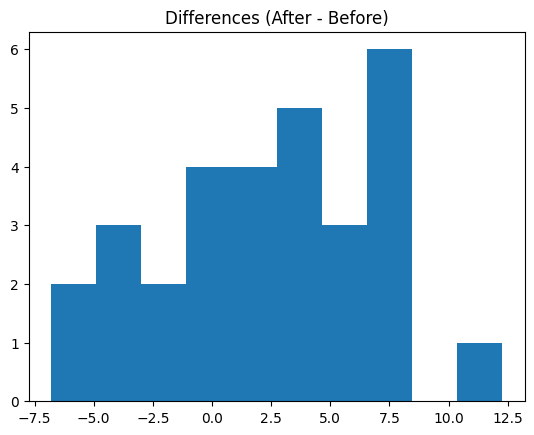

In [58]:
diff = after - before
plt.hist(diff, bins=10)
plt.title("Differences (After - Before)")
plt.show()

In [59]:
t_stat, p_value = st.ttest_rel(after, before)

print("t-statistic:", t_stat)
print("p-value:", p_value)

t-statistic: 2.816770457787654
p-value: 0.008638928473056043


In [60]:
p_value_one_tailed = p_value / 2

alpha = 0.05

if p_value_one_tailed < alpha:
    print("Reject H₀")
else:
    print("Fail to reject H₀")

Reject H₀


There is sufficient evidence that the new workflow tool increases employee productivity.